# Exercise - 1: Complete all the Task.


# 1.Read and display the image.


• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

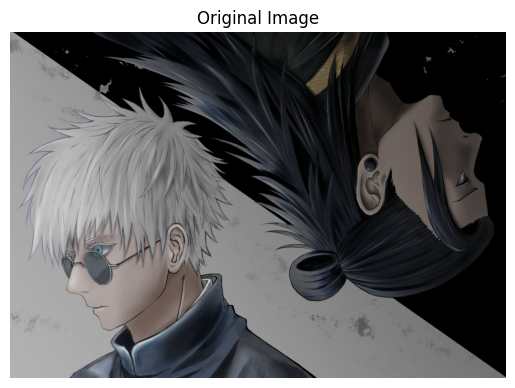

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


image = Image.open("/content/drive/MyDrive/Artificial Intelligence and Machine Learning/gg.jpg")


plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and **Array** Indexing.

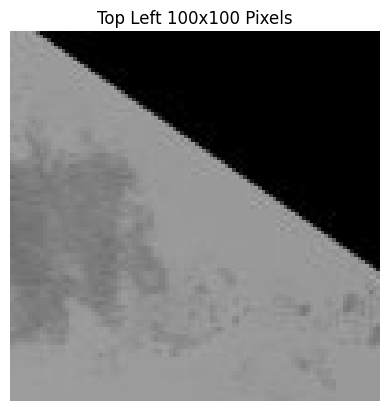

In [2]:
image_array = np.array(image)

top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

# 3.Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them individually, labeling each channel as R, G, and B.{Using NumPy.}

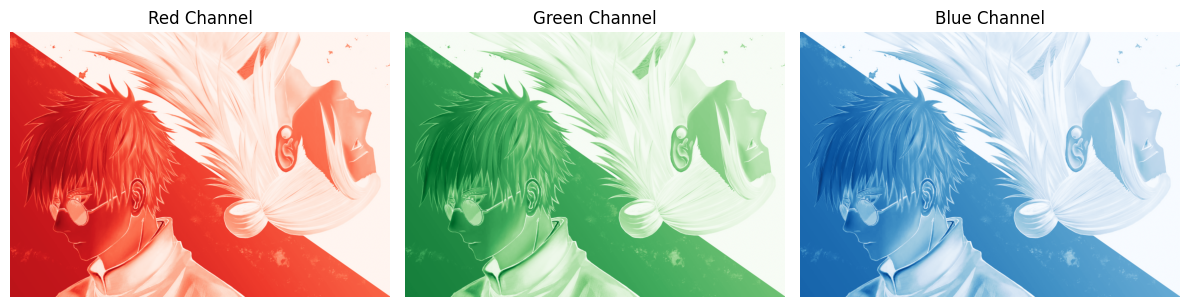

In [3]:
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(red_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

# 4.Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a light gray color), and then display the modified image.

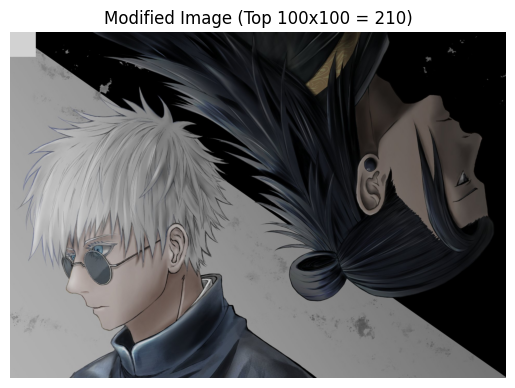

In [4]:
modified_image = image_array.copy()

modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

# Exercise - 2:

Complete all the Task.

# 1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

 • Display the grayscale image using matplotlib.

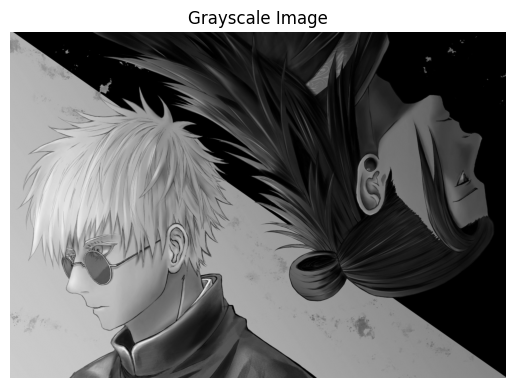

In [7]:
image_grayed = Image.open("//content/drive/MyDrive/Artificial Intelligence and Machine Learning/gg.jpg").convert("L")

image_array_grayed = np.array(image_grayed)

plt.imshow(image_array_grayed, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 2.Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

 • Display this cropped image using matplotlib.

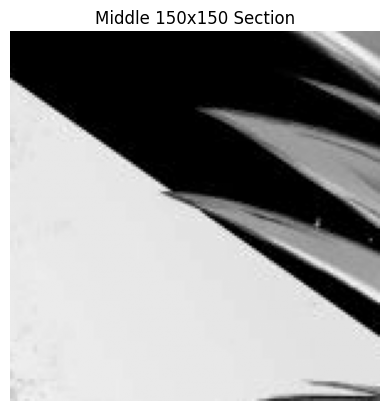

In [8]:
height, width = image_array_grayed.shape

center_h = height // 2
center_w = width // 2

middle_section = image_array_grayed[
    center_h-75:center_h+75,
    center_w-75:center_w+75
]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

# 3.Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values above 100 to 255 (creating a binary image).

• Display the resulting binary image

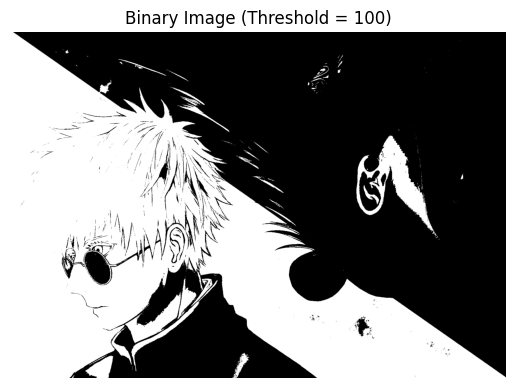

In [9]:
binary_image = np.where(image_array_grayed < 100, 0, 255)

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

# 4.Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating the image array.

• Display the rotated image using matplotlib.

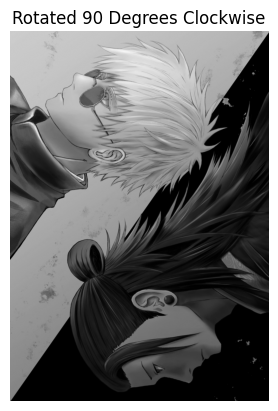

In [10]:
rotated_image = image_grayed.rotate(-90, expand=True)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

# 5.Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

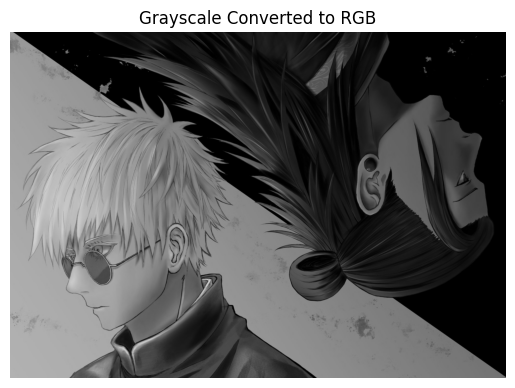

In [11]:
rgb_image = image_grayed.convert("RGB")

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

# 3. Image Compression and Decompression using PCA.

# 1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

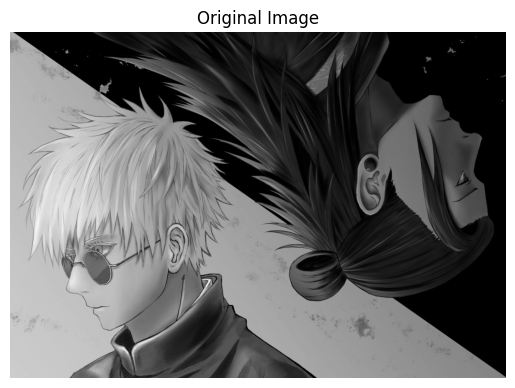

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open("//content/drive/MyDrive/Artificial Intelligence and Machine Learning/gg.jpg").convert("L")

image_array = np.array(image)

height, width = image_array.shape

data = image_array.reshape(height, width)

plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

 • Center the dataset - Standaridze the Data.

In [13]:
mean = np.mean(data, axis=0)
centered_data = data - mean

• Calculate the covaraince matrix of the Standaridze data.

In [14]:
cov_matrix = np.cov(centered_data, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (1920, 1920)


# 2.Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.

In [15]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues Shape:", eigenvalues.shape)
print("Eigenvectors Shape:", eigenvectors.shape)

Eigenvalues Shape: (1920,)
Eigenvectors Shape: (1920, 1920)


• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to the highest eigenvalues.

In [16]:
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


k = 50
top_k_eigenvectors = eigenvectors[:, :k]

print("Top k Eigenvectors Shape:", top_k_eigenvectors.shape)

Top k Eigenvectors Shape: (1920, 50)


•  Identify the Principal Components with the help of cumulative Sum plot.

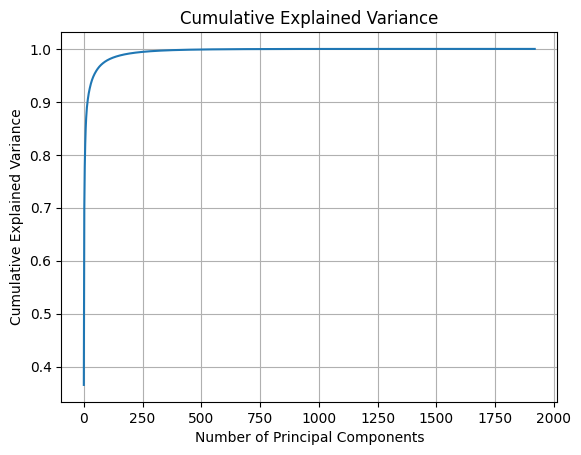

In [17]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# 3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec- tors(PCs) to obtain a lower-dimensional representation.

In [18]:
compressed_data = np.dot(centered_data, top_k_eigenvectors)

print("Compressed Data Shape:", compressed_data.shape)

Compressed Data Shape: (1341, 50)


In [19]:
reconstructed_image = np.dot(compressed_data, top_k_eigenvectors.T) + mean

print("Reconstructed Image Shape:", reconstructed_image.shape)

Reconstructed Image Shape: (1341, 1920)


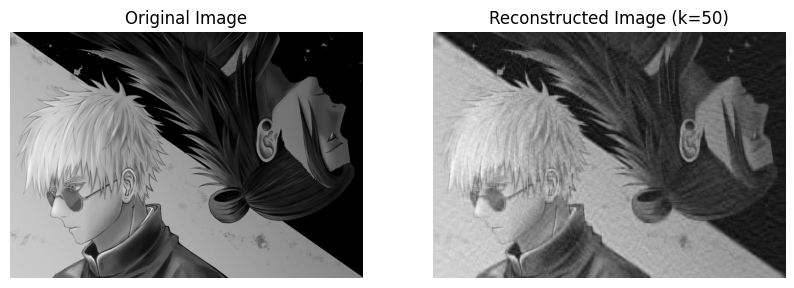

In [20]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

plt.show()

• Experiments: Pick Four different combination of principal components with various ex- plained variance value and compare the result.

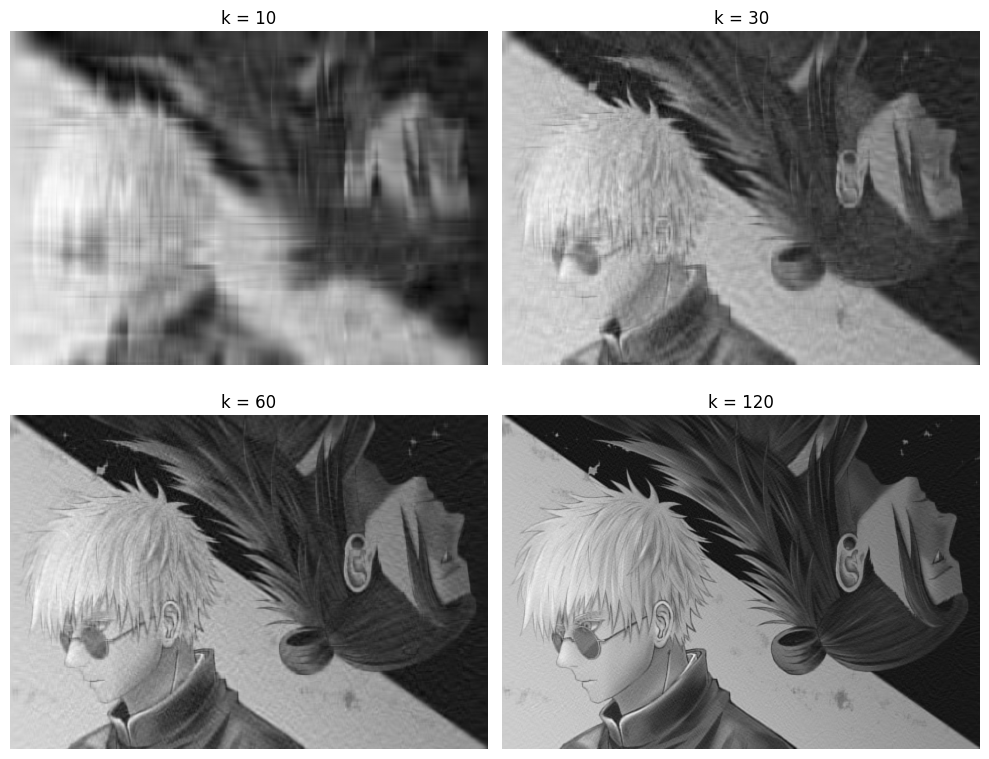

In [21]:
k_values = [10, 30, 60, 120]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):
    components = eigenvectors[:, :k]
    compressed = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

• Display the Results and Evaluate.








In this experiment, PCA was used to compress the image and then reconstruct it using different numbers of principal components (k values).

When only a small number of components was used such as k = 10, the reconstructed image looked blurry and many important details were missing. This happened because only a small amount of the image’s information was kept  so the reconstructed image could not fully match the original.

As the value of k increased (for example k = 30 and k = 60), the image quality gradually improved. More details from the original image became visible and the reconstruction looked clearer. This shows that using more principal components helps preserve more information from the original image.

When a larger value like k = 120 was used, the reconstructed image looked very similar to the original. This is because most of the important information (variance) was retained so very little detail was lost during compression.

From the cumulative explained variance graph, we can see that the curve rises quickly at first and then starts to level off. This means the first few principal components contain most of the important information. After a certain point adding more components does not significantly increase the explained variance.

Overall, this experiment shows that PCA is an effective technique for reducing data size while keeping the main features of an image. However, there is always a trade-off between compression and image quality so choosing the right value of k is important for achieving a good balance.



